# MacroAnchor CurveRV V1 — Macro-anchored tenor relative value

This notebook tests the natural extension of the MacroAnchor paper:

\[
\text{macro anchor} \rightarrow \text{HW short-rate central tendency} \rightarrow TP_{HW}(\tau,t)
\rightarrow \text{cross-tenor score} \rightarrow \text{curve RV / duration overlay}
\]

The point is not to add another optimized backtest. The point is to answer a precise research question:

> Does the macro-anchored affine term-premium signal contain **relative-value information across tenors**, or is it mainly a **long-duration / 10Y risk-premium timing signal**?

Strategies implemented:

1. **A — Long best tenor / cash**: hold the tenor with the highest score if the score is positive.
2. **B — Long top / short bottom**: self-financing score-spread trade.
3. **C — DV01-neutral long/short**: top-vs-bottom but duration-risk balanced, with cash residual.
4. **D — PC1-neutral curve RV**: score-sorted cross-tenor portfolio with level/PC1 exposure projected out.

Diagnostics:

- costs, turnover, drawdown;
- carry / roll-down / repricing / convexity / funding attribution;
- correlation and beta to static 10Y duration;
- average duration and level exposure;
- comparison against static 10Y, equal-weight 2–10Y basket and 10Y timing.

**Reading rule.** If only A and 10Y timing work, the signal is mostly a duration-risk-premium signal. If B/C/D survive costs and show low beta to 10Y, it becomes genuine yield-curve relative value.

In [1]:
# ===== 0. Settings =====
from pathlib import Path
import io
import urllib.request
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
plt.rcParams.update({"figure.dpi": 115, "font.size": 9, "axes.grid": True, "grid.alpha": 0.25})

START = "1961-01-01"
END = str(pd.Timestamp.today().date())
CACHE_DIR = Path("macroanchor_curve_rv_cache")
OUT_DIR = Path("macroanchor_curve_rv_outputs")
CACHE_DIR.mkdir(exist_ok=True)
OUT_DIR.mkdir(exist_ok=True)

# Main research settings
TENORS = [2, 3, 5, 7, 10]              # traded tenors
CURVE_MATS = [1, 2, 3, 5, 7, 10]       # observed CMT tenors used for interpolation
H = 12                                  # 12-month bond-risk-premium target
MINW = 120                              # expanding-window burn-in
PI_HL = 36                              # inflation trend EWMA half-life in months
RSTAR_HL = 120                          # neutral real-rate proxy half-life in months

# Score construction: "forecast_er_vol" or "tp_z"
SCORE_MODE = "forecast_er_vol"

# Strategy / implementation settings
VOL_TARGET = None       # e.g. 0.06 for 6% annualized ex-ante targeting; None leaves raw weights
VOL_LOOKBACK = 36
MAX_LEVERAGE = 2.0
REQUIRE_POSITIVE_FOR_LONG_ONLY = True
COST_BPS_GRID = [0, 5, 10, 25]

print("MacroAnchor CurveRV V1")
print("TENORS:", TENORS)
print("SCORE_MODE:", SCORE_MODE)

MacroAnchor CurveRV V1
TENORS: [2, 3, 5, 7, 10]
SCORE_MODE: forecast_er_vol


In [2]:
# ===== 1. Data layer: FRED with cache/fallback =====
def _read_fredgraph_csv(series_id: str) -> pd.Series:
    """Read one FRED series using fredgraph CSV; cache locally."""
    cache_path = CACHE_DIR / f"{series_id}.csv"
    if cache_path.exists():
        df = pd.read_csv(cache_path)
    else:
        url = f"https://fred.stlouisfed.org/graph/fredgraph.csv?id={series_id}"
        try:
            # avoid compressed responses that sometimes trigger decode issues
            req = urllib.request.Request(url, headers={"Accept-Encoding": "identity", "User-Agent": "Mozilla/5.0"})
            with urllib.request.urlopen(req, timeout=30) as resp:
                raw = resp.read()
            text = raw.decode("utf-8-sig", errors="replace")
            df = pd.read_csv(io.StringIO(text))
            df.to_csv(cache_path, index=False)
        except Exception as e:
            if cache_path.exists():
                warnings.warn(f"FRED download failed for {series_id}; using cache. Error: {e}")
                df = pd.read_csv(cache_path)
            else:
                raise RuntimeError(f"Cannot fetch {series_id} and no cache exists. Error: {e}")
    df.columns = ["date", "value"]
    df["date"] = pd.to_datetime(df["date"], errors="coerce")
    s = pd.to_numeric(df["value"], errors="coerce")
    return pd.Series(s.values, index=df["date"], name=series_id).sort_index()


def fred_series(ids, start=START, end=END) -> pd.DataFrame:
    ids = ids if isinstance(ids, list) else [ids]
    # Prefer pandas_datareader if available; fallback to cached fredgraph CSV
    try:
        import pandas_datareader.data as web
        df = web.DataReader(ids, "fred", start, end)
        if df is not None and len(df.dropna(how="all")):
            return df
    except Exception as e:
        warnings.warn(f"pandas_datareader failed ({e}); using fredgraph CSV/cache.")
    out = {sid: _read_fredgraph_csv(sid) for sid in ids}
    df = pd.DataFrame(out)
    return df.loc[pd.to_datetime(start):pd.to_datetime(end)]


def ewma(series, halflife):
    return pd.Series(series).ewm(halflife=halflife, adjust=False).mean()

In [3]:
# ===== 2. Fetch and align US curve, short rate, CPI =====
ids_curve = {1: "GS1", 2: "GS2", 3: "GS3", 5: "GS5", 7: "GS7", 10: "GS10"}
raw = fred_series(list(ids_curve.values()) + ["TB3MS", "CPIAUCSL"])
raw.index = pd.to_datetime(raw.index)
raw_m = raw.resample("ME").last()

curve = pd.DataFrame({m: raw_m[ids_curve[m]] for m in CURVE_MATS}) / 100.0
short = raw_m["TB3MS"] / 100.0
cpi = raw_m["CPIAUCSL"]

idx = curve.dropna().index.intersection(short.dropna().index).intersection(cpi.dropna().index)
curve = curve.loc[idx].copy()
short = short.loc[idx].copy()
cpi = cpi.loc[idx].copy()

# Trim to start where all relevant tenors are available
valid = curve.dropna().index.intersection(short.dropna().index).intersection(cpi.dropna().index)
curve, short, cpi = curve.loc[valid], short.loc[valid], cpi.loc[valid]
dates = curve.index
Y = curve.values.astype(float)
r = short.values.astype(float)
Tn = len(dates)
TAUS = np.array(CURVE_MATS, dtype=float)

print(f"Sample: {dates[0].date()} to {dates[-1].date()} | n={Tn}")
print("Curve columns:", curve.columns.tolist())
display(curve.tail())

Sample: 1976-06-30 to 2026-05-31 | n=599
Curve columns: [1, 2, 3, 5, 7, 10]


,1,2,3,5,7,10
DATE,,,,,,
2026-01-31,0.0351,0.0354,0.0361,0.0378,0.0399,0.0421
2026-02-28,0.0348,0.0347,0.0352,0.0368,0.0389,0.0413
2026-03-31,0.0367,0.0371,0.0373,0.0385,0.0404,0.0425
2026-04-30,0.0369,0.0380,0.0382,0.0394,0.0412,0.0432
2026-05-31,0.0379,0.0400,0.0404,0.0415,0.0431,0.0448


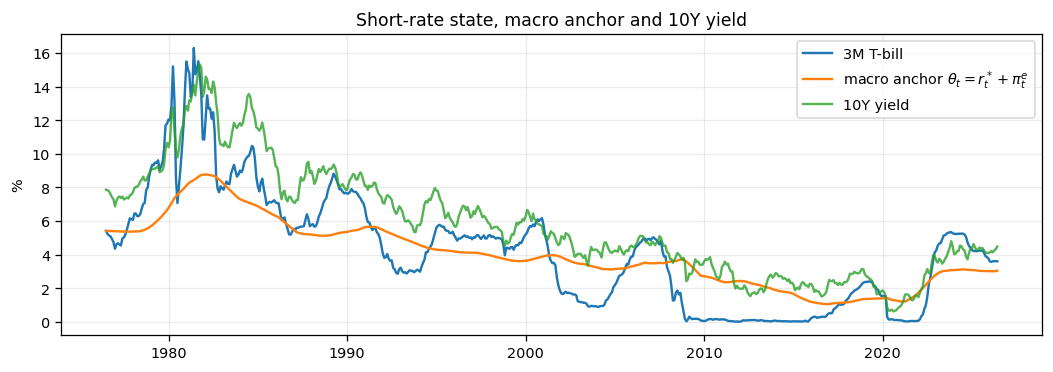

Latest:
3M rate: 3.60% | r*: -0.24% | pi_e: 3.28% | anchor: 3.04%


In [4]:
# ===== 3. Macro anchor: theta(t) = r*_t + pi_e,t =====
# Trend inflation: EWMA of trailing YoY CPI.
# r*: slow EWMA of realized real short rate, deliberately simple and reproducible.
cpi_yoy = np.log(cpi).diff(12)
pi_trend = cpi_yoy.ewm(halflife=PI_HL, adjust=False).mean().bfill()
rstar = (short - pi_trend).ewm(halflife=RSTAR_HL, adjust=False).mean().bfill()
anchor = (rstar + pi_trend).reindex(dates).bfill().ffill()

plt.figure(figsize=(11, 3.4))
plt.plot(dates, short * 100, label="3M T-bill")
plt.plot(dates, anchor * 100, label=r"macro anchor $\theta_t=r^*_t+\pi^e_t$")
plt.plot(dates, curve[10] * 100, label="10Y yield", alpha=0.8)
plt.title("Short-rate state, macro anchor and 10Y yield")
plt.ylabel("%")
plt.legend()
plt.show()

print("Latest:")
print(f"3M rate: {short.iloc[-1]*100:.2f}% | r*: {rstar.iloc[-1]*100:.2f}% | pi_e: {pi_trend.iloc[-1]*100:.2f}% | anchor: {anchor.iloc[-1]*100:.2f}%")

Full-sample-ish latest expanding HW estimate:
kappa=0.1621, half-life=51.3m, sigma=1.48%, gap t=1.52


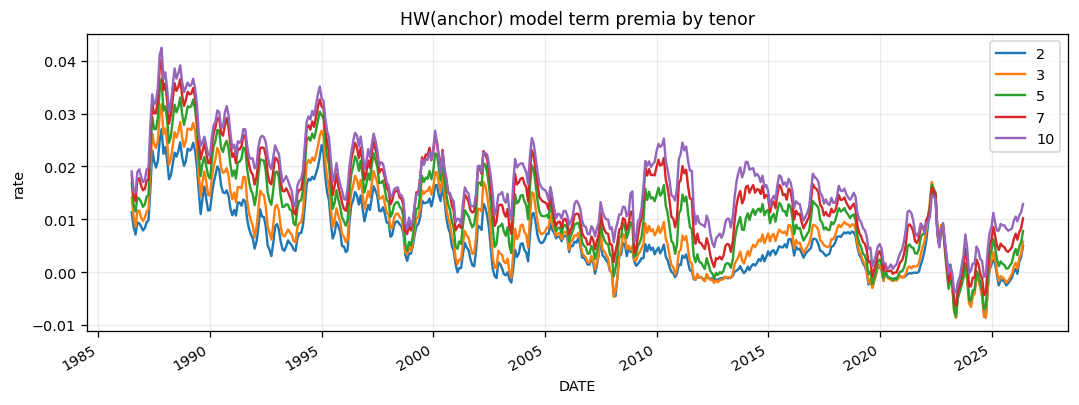

In [5]:
# ===== 4. HW(anchor) estimation under P and pure-expectations term premia =====
DT = 1/12

def fit_hw(rw, anc):
    """Regress monthly dr on anchor gap; annualize kappa/sigma."""
    rw = np.asarray(rw, float); anc = np.asarray(anc, float)
    g = anc[:len(rw)-1] - rw[:-1]
    d = rw[1:] - rw[:-1]
    m = np.isfinite(g) & np.isfinite(d)
    if m.sum() < 24 or np.nanvar(g[m]) < 1e-12:
        return np.nan, np.nan, np.nan
    X = np.column_stack([np.ones(m.sum()), g[m]])
    a0, sl = np.linalg.lstsq(X, d[m], rcond=None)[0]
    e = d[m] - (a0 + sl*g[m])
    denom = np.sum((g[m] - g[m].mean())**2)
    if denom <= 0 or len(e) <= 2:
        tstat = np.nan
    else:
        seb = np.sqrt(np.sum(e*e)/(len(e)-2)/denom)
        tstat = sl/seb if seb > 0 else np.nan
    k = float(np.clip(sl * 12, 1e-4, 20.0))
    sigma = float(np.nanstd(e) * np.sqrt(12))
    return k, sigma, float(tstat)


def vas_B(tau, k):
    k = max(float(k), 1e-4)
    return (1 - np.exp(-k*tau)) / k


def vas_yield(tau, rr, k, theta, sigma):
    k = max(float(k), 1e-4)
    B = vas_B(tau, k)
    lnA = (theta - sigma*sigma/(2*k*k))*(B - tau) - sigma*sigma*B*B/(4*k)
    return (-lnA + B*rr) / tau

# Expanding estimates
k_hw = np.full(Tn, np.nan)
sig_hw = np.full(Tn, np.nan)
t_hw = np.full(Tn, np.nan)
for t in range(MINW, Tn):
    k_hw[t], sig_hw[t], t_hw[t] = fit_hw(r[:t+1], anchor.values[:t+1])

# Model-implied pure-expectations yields and term premia by observed tenor
YPE = np.full_like(Y, np.nan, dtype=float)
TPHW = np.full_like(Y, np.nan, dtype=float)
for t in range(MINW, Tn):
    for j, tau in enumerate(TAUS):
        YPE[t, j] = vas_yield(tau, r[t], k_hw[t], anchor.iloc[t], sig_hw[t])
        TPHW[t, j] = Y[t, j] - YPE[t, j]

tp_df = pd.DataFrame(TPHW, index=dates, columns=CURVE_MATS)
print("Full-sample-ish latest expanding HW estimate:")
print(f"kappa={k_hw[np.isfinite(k_hw)][-1]:.4f}, half-life={np.log(2)/k_hw[np.isfinite(k_hw)][-1]*12:.1f}m, sigma={sig_hw[np.isfinite(sig_hw)][-1]*100:.2f}%, gap t={t_hw[np.isfinite(t_hw)][-1]:.2f}")

tp_df[TENORS].plot(figsize=(11, 3.8), title="HW(anchor) model term premia by tenor")
plt.ylabel("rate")
plt.show()

In [6]:
# ===== 5. Exact 12m Fama-Bliss-style targets and monthly excess returns =====
def y_at_date(t, mat):
    return float(np.interp(mat, TAUS, Y[t]))

# 12m exact excess return per tenor: rx_t = n*y_t(n) - (n-1)*y_{t+12}(n-1) - y_t(1)
RX12 = pd.DataFrame(index=dates, columns=TENORS, dtype=float)
y1 = curve[1].values
for n in TENORS:
    for t in range(Tn - H):
        yn = y_at_date(t, n)
        ynm1_next = y_at_date(t + H, n - 1)
        RX12.iloc[t, RX12.columns.get_loc(n)] = n*yn - (n-1)*ynm1_next - y1[t]

# Monthly holding-period return approximation by component.
# Position held from t-1 to t; components are computed at t using previous curve and realised yield change.
ret_total = pd.DataFrame(index=dates, columns=TENORS, dtype=float)
ret_excess = pd.DataFrame(index=dates, columns=TENORS, dtype=float)
comp = {name: pd.DataFrame(index=dates, columns=TENORS, dtype=float) for name in ["carry", "roll", "repricing", "convexity", "funding"]}

for t in range(1, Tn):
    for n in TENORS:
        y_prev = y_at_date(t-1, n)
        y_prev_aged = y_at_date(t-1, max(n - 1/12, 0.25))
        y_now = y_at_date(t, n)
        y_prev_same = y_at_date(t-1, n)
        dy = y_now - y_prev_same
        D = n
        C = n*n
        carry = y_prev / 12
        roll = D * (y_prev - y_prev_aged)
        repricing = -D * dy
        convexity = 0.5 * C * dy * dy
        funding = -short.iloc[t-1] / 12
        total = carry + roll + repricing + convexity
        comp["carry"].iloc[t, comp["carry"].columns.get_loc(n)] = carry
        comp["roll"].iloc[t, comp["roll"].columns.get_loc(n)] = roll
        comp["repricing"].iloc[t, comp["repricing"].columns.get_loc(n)] = repricing
        comp["convexity"].iloc[t, comp["convexity"].columns.get_loc(n)] = convexity
        comp["funding"].iloc[t, comp["funding"].columns.get_loc(n)] = funding
        ret_total.iloc[t, ret_total.columns.get_loc(n)] = total
        ret_excess.iloc[t, ret_excess.columns.get_loc(n)] = total + funding

print("12m exact targets preview:")
display(RX12[TENORS].dropna().head())
print("Monthly excess return approximation preview:")
display(ret_excess[TENORS].dropna().head())

12m exact targets preview:


,2,3,5,7,10
DATE,,,,,
1976-06-30,0.0180,0.0315,0.0523,0.0630,0.0725
1976-07-31,0.0156,0.0262,0.0455,0.0582,0.0676
1976-08-31,0.0089,0.0136,0.0291,0.0425,0.0558
1976-09-30,0.0047,0.0072,0.0205,0.0328,0.0439
1976-10-31,-0.0051,-0.0100,-0.0077,0.0034,0.0116


Monthly excess return approximation preview:


,2,3,5,7,10
DATE,,,,,
1976-07-31,0.0065,0.0079,0.0085,0.0059,0.0054
1976-08-31,0.0068,0.0101,0.0117,0.0111,0.0085
1976-09-30,0.0065,0.0080,0.0118,0.0148,0.0209
1976-10-31,0.0109,0.0146,0.0219,0.0204,0.0208
1976-11-30,0.0051,0.0063,0.0142,0.0243,0.0148


In [7]:
# ===== 6. Expanding forecasts, z-scores and cross-tenor scores =====
def nw_tstat(y, x, lag=12):
    y = np.asarray(y, float); x = np.asarray(x, float)
    m = np.isfinite(y) & np.isfinite(x)
    y = y[m]; x = x[m]
    if len(y) < 36 or np.nanstd(x) < 1e-12:
        return np.nan, np.nan, np.nan
    X = np.column_stack([np.ones(len(x)), x])
    b = np.linalg.lstsq(X, y, rcond=None)[0]
    e = y - X @ b
    Z = X * e[:, None]
    S = Z.T @ Z / len(y)
    for L in range(1, min(lag, len(y)-1) + 1):
        w = 1 - L/(lag + 1)
        Gamma = Z[L:].T @ Z[:-L] / len(y)
        S += w * (Gamma + Gamma.T)
    XX = X.T @ X / len(y)
    V = np.linalg.pinv(XX) @ S @ np.linalg.pinv(XX) / len(y)
    se = np.sqrt(np.diag(V))
    t = b[1]/se[1] if se[1] > 0 else np.nan
    r2 = 1 - np.sum(e*e)/np.sum((y - y.mean())**2)
    return b[1], t, r2


def expanding_forecast(x, y, minw=MINW, horizon=H):
    """Forecast y[t] using x[t], training only on origins s<=t-horizon."""
    x = np.asarray(x, float); y = np.asarray(y, float)
    yhat = np.full(len(y), np.nan)
    volhat = np.full(len(y), np.nan)
    beta = np.full(len(y), np.nan)
    for t in range(minw + horizon, len(y)):
        train_idx = np.arange(0, t - horizon + 1)
        m = np.isfinite(x[train_idx]) & np.isfinite(y[train_idx])
        if m.sum() < minw or not np.isfinite(x[t]):
            continue
        X = np.column_stack([np.ones(m.sum()), x[train_idx][m]])
        b = np.linalg.lstsq(X, y[train_idx][m], rcond=None)[0]
        res = y[train_idx][m] - X @ b
        yhat[t] = b[0] + b[1]*x[t]
        volhat[t] = np.nanstd(res)
        beta[t] = b[1]
    return yhat, volhat, beta


def expanding_z(x, minw=MINW):
    x = np.asarray(x, float)
    z = np.full(len(x), np.nan)
    for t in range(minw, len(x)):
        hist = x[:t]
        hist = hist[np.isfinite(hist)]
        if len(hist) < minw or hist.std() < 1e-12 or not np.isfinite(x[t]):
            continue
        z[t] = (x[t] - hist.mean()) / hist.std()
    return z

# Build tenor-level predictors and scores.
forecast_er = pd.DataFrame(index=dates, columns=TENORS, dtype=float)
forecast_vol = pd.DataFrame(index=dates, columns=TENORS, dtype=float)
tp_z = pd.DataFrame(index=dates, columns=TENORS, dtype=float)
beta_exp = pd.DataFrame(index=dates, columns=TENORS, dtype=float)
insample_rows = []

for n in TENORS:
    x = tp_df[n].values
    y = RX12[n].values
    yh, vh, bh = expanding_forecast(x, y)
    forecast_er[n] = yh
    forecast_vol[n] = vh
    beta_exp[n] = bh
    tp_z[n] = expanding_z(x)
    b, tstat, r2 = nw_tstat(y, x, lag=12)
    insample_rows.append({"tenor": n, "beta_per_1SD_%": b*np.nanstd(x)*100 if np.isfinite(b) else np.nan, "NW_t": tstat, "R2": r2})

if SCORE_MODE == "forecast_er_vol":
    score = forecast_er / forecast_vol.replace(0, np.nan)
elif SCORE_MODE == "tp_z":
    score = tp_z.copy()
else:
    raise ValueError("Unknown SCORE_MODE")

score = score.replace([np.inf, -np.inf], np.nan)
print("In-sample predictive regressions: RX12 ~ TP_HW")
display(pd.DataFrame(insample_rows).set_index("tenor"))
print("Score preview")
display(score.dropna(how="all").tail())

In-sample predictive regressions: RX12 ~ TP_HW


,beta_per_1SD_%,NW_t,R2
tenor,,,
2,0.2958,2.1433,0.0479
3,0.5263,2.0370,0.0441
5,1.2511,2.5543,0.0771
7,1.9915,2.9967,0.1071
10,3.2033,3.4271,0.1478


Score preview


,2,3,5,7,10
DATE,,,,,
2026-01-31,0.2483,0.2066,0.1557,0.1275,0.0534
2026-02-28,0.2181,0.1771,0.1173,0.0839,0.0114
2026-03-31,0.2962,0.2342,0.1741,0.1422,0.0674
2026-04-30,0.3257,0.2585,0.2038,0.1722,0.0981
2026-05-31,0.3942,0.3203,0.2755,0.2467,0.1730


In [8]:
# ===== 7. Strategy weight builders =====
def normalize_gross(w, gross=1.0):
    w = np.asarray(w, float)
    g = np.nansum(np.abs(w))
    if not np.isfinite(g) or g <= 1e-12:
        return np.zeros_like(w)
    return w / g * gross


def weights_A_long_best(score_df):
    W = pd.DataFrame(0.0, index=score_df.index, columns=score_df.columns)
    for t, row in score_df.iterrows():
        x = row.astype(float)
        if x.notna().sum() == 0:
            continue
        best = x.idxmax()
        if REQUIRE_POSITIVE_FOR_LONG_ONLY and x.loc[best] <= 0:
            continue
        W.loc[t, best] = 1.0
    return W


def weights_B_top_bottom(score_df, gross=1.0):
    W = pd.DataFrame(0.0, index=score_df.index, columns=score_df.columns)
    for t, row in score_df.iterrows():
        x = row.astype(float).dropna()
        if len(x) < 2:
            continue
        long_n, short_n = x.idxmax(), x.idxmin()
        if x.loc[long_n] <= x.loc[short_n]:
            continue
        W.loc[t, long_n] = gross/2
        W.loc[t, short_n] = -gross/2
    return W


def weights_C_dv01_neutral(score_df, durations, gross=1.0):
    """Top-bottom trade with equal and opposite DV01, plus implicit cash residual.
    Dollar weights do not sum to zero unless durations are equal; returns are active over cash via excess returns.
    """
    W = pd.DataFrame(0.0, index=score_df.index, columns=score_df.columns)
    D = pd.Series(durations, index=score_df.columns, dtype=float)
    for t, row in score_df.iterrows():
        x = row.astype(float).dropna()
        if len(x) < 2:
            continue
        L, S = x.idxmax(), x.idxmin()
        if x.loc[L] <= x.loc[S]:
            continue
        dL, dS = D.loc[L], D.loc[S]
        wL = gross * dS / (dL + dS)
        wS = -gross * dL / (dL + dS)
        W.loc[t, L] = wL
        W.loc[t, S] = wS
    return W


def pc1_loadings_at(t, lookback=60):
    if t < lookback + 1:
        return None
    dY_hist = curve.diff().iloc[t-lookback:t].dropna()
    if len(dY_hist) < max(24, lookback//2):
        return None
    X = dY_hist[CURVE_MATS].values
    X = X - X.mean(axis=0, keepdims=True)
    cov = np.cov(X, rowvar=False)
    vals, vecs = np.linalg.eigh(cov)
    pc1 = vecs[:, np.argmax(vals)]
    # Orient PC1 to have positive average loading.
    if pc1.mean() < 0:
        pc1 = -pc1
    # Interpolate PC1 loadings to traded tenors.
    return np.interp(TENORS, CURVE_MATS, pc1)


def weights_D_pc1_neutral(score_df, gross=1.0, lookback=60):
    W = pd.DataFrame(0.0, index=score_df.index, columns=score_df.columns)
    D = np.array(TENORS, dtype=float)
    for i, (dt, row) in enumerate(score_df.iterrows()):
        x = row.astype(float).values
        if np.isfinite(x).sum() < 3:
            continue
        # Raw score-sorted portfolio: demean scores, then gross-normalize.
        z = x.copy()
        z[~np.isfinite(z)] = np.nan
        z = z - np.nanmean(z)
        z[~np.isfinite(z)] = 0.0
        w = normalize_gross(z, gross=gross)
        pc1 = pc1_loadings_at(i, lookback=lookback)
        if pc1 is None:
            continue
        # Bond return exposure to PC1 yield move is roughly -D * pc1.
        load = -D * pc1
        denom = float(load @ load)
        if denom > 1e-12:
            w = w - (float(w @ load) / denom) * load
        w = normalize_gross(w, gross=gross)
        W.loc[dt, :] = w
    return W

W = {
    "A_long_best": weights_A_long_best(score),
    "B_top_bottom": weights_B_top_bottom(score),
    "C_DV01_neutral": weights_C_dv01_neutral(score, durations=TENORS),
    "D_PC1_neutral": weights_D_pc1_neutral(score),
}

for k, w in W.items():
    print(k, "avg gross", w.abs().sum(1).replace(0, np.nan).mean(), "avg net", w.sum(1).replace(0, np.nan).mean())

A_long_best avg gross 1.0 avg net 1.0
B_top_bottom avg gross 1.0 avg net nan
C_DV01_neutral avg gross 1.0 avg net 0.6343929378412139
D_PC1_neutral avg gross 1.0 avg net 0.5198987248788418


In [9]:
# ===== 8. Backtest, costs, turnover, diagnostics =====
def lag_weights(w):
    return w.shift(1).fillna(0.0)


def strategy_returns(weights, ret_excess_df, cost_bps=0.0):
    Wlag = lag_weights(weights)
    gross_ret = (Wlag * ret_excess_df[weights.columns]).sum(axis=1)
    turnover = weights.diff().abs().sum(axis=1).fillna(weights.abs().sum(axis=1))
    cost = turnover * (cost_bps / 10000.0)
    return gross_ret - cost, gross_ret, cost, turnover


def max_drawdown(r):
    r = pd.Series(r).dropna()
    if len(r) == 0:
        return np.nan
    wealth = (1 + r).cumprod()
    dd = wealth / wealth.cummax() - 1
    return dd.min()


def perf_stats(r, turnover=None, name=None):
    r = pd.Series(r).replace([np.inf, -np.inf], np.nan).dropna()
    if len(r) < 24 or r.std() == 0:
        return {"name": name, "n": len(r)}
    out = {
        "name": name,
        "n": len(r),
        "ann_ret": r.mean()*12,
        "ann_vol": r.std()*np.sqrt(12),
        "Sharpe": r.mean()/r.std()*np.sqrt(12),
        "MaxDD": max_drawdown(r),
        "hit_rate": (r > 0).mean(),
    }
    if turnover is not None:
        to = pd.Series(turnover).reindex(r.index).dropna()
        out["ann_turnover"] = to.mean()*12 if len(to) else np.nan
    return out

# Benchmarks
bench = {}
bench["Static_10Y_excess"] = ret_excess[10]
bench["EW_2_10Y_excess"] = ret_excess[TENORS].mean(axis=1)
# 10Y timing: sign of 10Y score, lagged and invested in 10Y excess.
w10 = pd.DataFrame(0.0, index=dates, columns=TENORS)
w10[10] = np.where(score[10] > 0, 1.0, 0.0)
W["E_10Y_timing"] = w10

# Optional volatility targeting using realized strategy vol, applied to weights recursively by simple ex-post lookback.
def apply_vol_target(weights, ret_excess_df, target=VOL_TARGET, lookback=VOL_LOOKBACK, max_lev=MAX_LEVERAGE):
    if target is None:
        return weights.copy()
    r0, _, _, _ = strategy_returns(weights, ret_excess_df, cost_bps=0.0)
    vol = r0.rolling(lookback).std() * np.sqrt(12)
    scale = (target / vol).clip(upper=max_lev).shift(1).fillna(0.0)
    return weights.mul(scale, axis=0)

W_used = {k: apply_vol_target(w, ret_excess) for k, w in W.items()}

rows = []
all_returns = {}
all_turnover = {}
for name, bret in bench.items():
    all_returns[name] = bret
    rows.append(perf_stats(bret.loc[dates[MINW+H:]], name=name))

for cost_bps in COST_BPS_GRID:
    for name, weights in W_used.items():
        r_net, r_gross, cost, to = strategy_returns(weights, ret_excess, cost_bps=cost_bps)
        nm = f"{name}_cost{cost_bps}bp"
        all_returns[nm] = r_net
        all_turnover[nm] = to
        rows.append(perf_stats(r_net.loc[dates[MINW+H:]], turnover=to.loc[dates[MINW+H:]], name=nm))

perf = pd.DataFrame(rows).set_index("name")
perf.to_csv(OUT_DIR / "curve_rv_performance.csv")
display(perf.sort_values("Sharpe", ascending=False))

,n,ann_ret,ann_vol,Sharpe,MaxDD,hit_rate,ann_turnover
name,,,,,,,
A_long_best_cost0bp,467,0.0086,0.0150,0.5722,-0.0911,0.4454,0.3854
EW_2_10Y_excess,467,0.0243,0.0426,0.5702,-0.1963,0.5782,NaN
A_long_best_cost5bp,467,0.0084,0.0149,0.5640,-0.0911,0.4454,0.3854
A_long_best_cost10bp,467,0.0082,0.0148,0.5552,-0.0911,0.4454,0.3854
A_long_best_cost25bp,467,0.0076,0.0145,0.5258,-0.0911,0.4454,0.3854
Static_10Y_excess,467,0.0359,0.0779,0.4605,-0.3243,0.5782,NaN
E_10Y_timing_cost0bp,467,0.0152,0.0478,0.3169,-0.2402,0.2398,0.6938
E_10Y_timing_cost5bp,467,0.0148,0.0477,0.3102,-0.2432,0.2377,0.6938
E_10Y_timing_cost10bp,467,0.0145,0.0477,0.3034,-0.2462,0.2377,0.6938


In [10]:
# ===== 9. RV versus duration timing diagnostics =====
def ols_beta_alpha(y, x):
    df = pd.concat([pd.Series(y, name="y"), pd.Series(x, name="x")], axis=1).dropna()
    if len(df) < 36 or df["x"].std() == 0:
        return np.nan, np.nan, np.nan
    X = np.column_stack([np.ones(len(df)), df["x"].values])
    b = np.linalg.lstsq(X, df["y"].values, rcond=None)[0]
    res = df["y"].values - X @ b
    r2 = 1 - np.sum(res*res)/np.sum((df["y"] - df["y"].mean())**2)
    return b[0]*12, b[1], r2

# Exposure diagnostics: net dollar, gross, duration, approximate PC1/level loading.
expo_rows = []
static10 = ret_excess[10].loc[dates[MINW+H:]]
ewbasket = ret_excess[TENORS].mean(1).loc[dates[MINW+H:]]
Dvec = pd.Series(TENORS, index=TENORS, dtype=float)
for name, weights in W_used.items():
    Wlag = lag_weights(weights)
    avg_net = Wlag.sum(1).loc[dates[MINW+H:]].mean()
    avg_gross = Wlag.abs().sum(1).loc[dates[MINW+H:]].mean()
    avg_dur = (Wlag * Dvec).sum(1).loc[dates[MINW+H:]].mean()
    r0, _, _, to = strategy_returns(weights, ret_excess, cost_bps=0.0)
    r_eval = r0.loc[dates[MINW+H:]]
    a10, b10, r2_10 = ols_beta_alpha(r_eval, static10)
    aew, bew, r2_ew = ols_beta_alpha(r_eval, ewbasket)
    expo_rows.append({
        "strategy": name,
        "avg_net_$": avg_net,
        "avg_gross_$": avg_gross,
        "avg_duration_exposure": avg_dur,
        "ann_turnover": to.loc[dates[MINW+H:]].mean()*12,
        "alpha_vs_10Y_ann": a10,
        "beta_vs_10Y": b10,
        "R2_vs_10Y": r2_10,
        "alpha_vs_EW_ann": aew,
        "beta_vs_EW": bew,
        "R2_vs_EW": r2_ew,
    })

expo = pd.DataFrame(expo_rows).set_index("strategy")
expo.to_csv(OUT_DIR / "curve_rv_exposure_diagnostics.csv")
display(expo)

print("Reading rule:")
print("- High beta/R2 to 10Y means duration timing, not genuine RV.")
print("- Low beta to 10Y + positive Sharpe after costs in B/C/D is evidence of cross-tenor RV.")

,avg_net_$,avg_gross_$,avg_duration_exposure,ann_turnover,alpha_vs_10Y_ann,beta_vs_10Y,R2_vs_10Y,alpha_vs_EW_ann,beta_vs_EW,R2_vs_EW
strategy,,,,,,,,,,
A_long_best,0.7388,0.7388,1.5289,0.3854,0.0046,0.1116,0.3361,0.0032,0.2214,0.3957
B_top_bottom,0.0000,0.7430,-2.7880,0.4882,0.0042,-0.2679,0.6102,0.0057,-0.4584,0.5347
C_DV01_neutral,0.4713,0.7430,0.0000,0.4306,0.0030,-0.0254,0.0836,0.0026,-0.0226,0.0199
D_PC1_neutral,0.3863,0.7430,0.0106,0.9466,0.0030,-0.0278,0.0976,0.0027,-0.0276,0.0287
E_10Y_timing,0.3961,0.3961,3.9615,0.6938,0.0018,0.3723,0.3680,0.0000,0.6231,0.3085


Reading rule:
- High beta/R2 to 10Y means duration timing, not genuine RV.
- Low beta to 10Y + positive Sharpe after costs in B/C/D is evidence of cross-tenor RV.


In [11]:
# ===== 10. Attribution: carry, roll, repricing, convexity, funding, costs =====
def attribution(weights, cost_bps=0.0):
    Wlag = lag_weights(weights)
    out = {}
    for cname, cdf in comp.items():
        out[cname] = (Wlag * cdf[weights.columns]).sum(axis=1)
    turnover = weights.diff().abs().sum(axis=1).fillna(weights.abs().sum(axis=1))
    out["cost"] = -turnover * (cost_bps/10000.0)
    out["total"] = sum(out[k] for k in ["carry", "roll", "repricing", "convexity", "funding"]) + out["cost"]
    return pd.DataFrame(out)

attr_rows = []
ATTR = {}
for name, weights in W_used.items():
    A = attribution(weights, cost_bps=10.0)
    ATTR[name] = A
    eval_A = A.loc[dates[MINW+H:]].dropna()
    row = {"strategy": name}
    for col in ["carry", "roll", "repricing", "convexity", "funding", "cost", "total"]:
        row[col + "_ann"] = eval_A[col].mean()*12
    attr_rows.append(row)

attr_summary = pd.DataFrame(attr_rows).set_index("strategy")
attr_summary.to_csv(OUT_DIR / "curve_rv_attribution_10bp.csv")
display(attr_summary)

,carry_ann,roll_ann,repricing_ann,convexity_ann,funding_ann,cost_ann,total_ann
strategy,,,,,,,
A_long_best,0.0191,0.0026,0.0027,0.0001,-0.0159,-0.0004,0.0082
B_top_bottom,-0.0031,-0.0014,-0.0000,-0.0009,0.0000,-0.0005,-0.0059
C_DV01_neutral,0.0115,0.0010,0.0006,-0.0003,-0.0107,-0.0004,0.0016
D_PC1_neutral,0.0095,0.0009,0.0007,-0.0003,-0.0088,-0.0009,0.0011
E_10Y_timing,0.0123,0.0041,0.0018,0.0011,-0.0041,-0.0007,0.0145


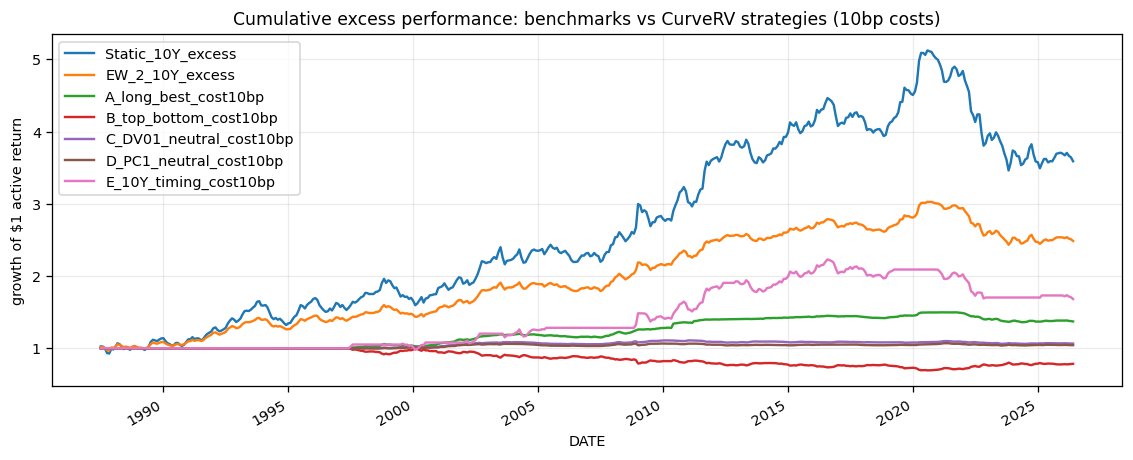

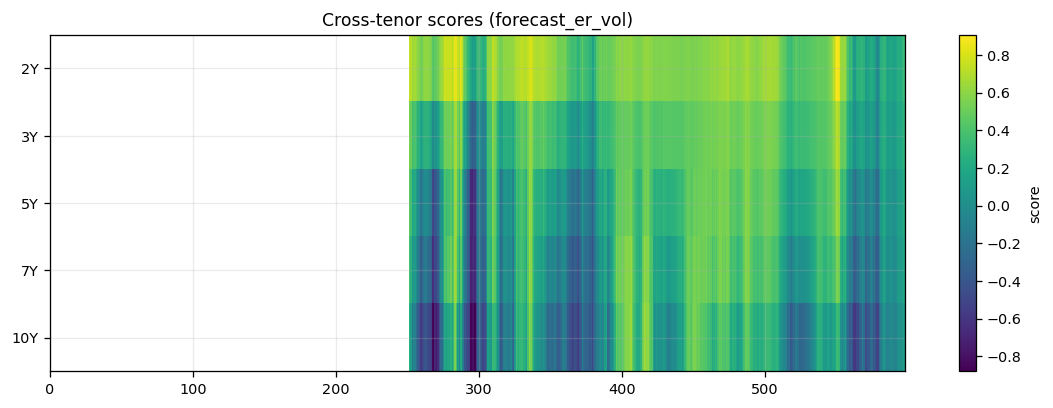

,2,3,5,7,10
A_long_best,0.7345,0.0000,0.0000,0.0000,0.0064
B_top_bottom,0.3694,-0.0161,-0.0086,-0.0011,-0.3437
C_DV01_neutral,0.6075,-0.0152,-0.0049,-0.0005,-0.1141
D_PC1_neutral,0.3421,0.1318,0.0380,0.0051,-0.1295
E_10Y_timing,0.0000,0.0000,0.0000,0.0000,0.3983


In [12]:
# ===== 11. Plots: cumulative performance and weights =====
eval_start = dates[MINW + H]
plot_names = ["Static_10Y_excess", "EW_2_10Y_excess"] + [f"{k}_cost10bp" for k in W_used]
ret_plot = pd.DataFrame({nm: all_returns[nm] for nm in plot_names if nm in all_returns}).loc[eval_start:].dropna(how="all")
wealth = (1 + ret_plot.fillna(0)).cumprod()
wealth.plot(figsize=(12, 4.5), title="Cumulative excess performance: benchmarks vs CurveRV strategies (10bp costs)")
plt.ylabel("growth of $1 active return")
plt.show()

# Score heatmap
plt.figure(figsize=(12, 3.8))
plt.imshow(score[TENORS].T, aspect="auto", interpolation="nearest", extent=[0, len(score)-1, len(TENORS)-0.5, -0.5])
plt.yticks(range(len(TENORS)), [f"{n}Y" for n in TENORS])
plt.title(f"Cross-tenor scores ({SCORE_MODE})")
plt.colorbar(label="score")
plt.show()

# Average weights
avgw = pd.DataFrame({name: w.loc[eval_start:].mean() for name, w in W_used.items()}).T
avgw.to_csv(OUT_DIR / "curve_rv_average_weights.csv")
display(avgw)

## Verdict template to paste into the paper/project notes

Use this after running the notebook:

1. **If A and E_10Y_timing dominate, but B/C/D are weak:**
   > The macro-anchored affine signal is primarily a long-duration bond-risk-premium signal. Cross-tenor RV does not add robust economic value once duration exposure is neutralized.

2. **If B survives costs but C/D weaken:**
   > There is score-spread information across tenors, but most of the payoff is still linked to duration imbalance. It is better framed as tenor selection / duration allocation than pure curve RV.

3. **If C or D survive costs with low 10Y beta:**
   > The model term-premium surface contains genuine relative-value information across the curve. This upgrades the project from a 10Y bond-risk-premium paper to a macro-anchored yield-curve relative-value paper.

4. **If all RV versions fail:**
   > Keep the CurveRV notebook as a negative appendix. The failure is still informative and reinforces the current paper’s claim hierarchy: 10Y risk premium first; curve RV only if separately validated.

In [13]:
# ===== 12. Export compact audit bundle =====
score.to_csv(OUT_DIR / "curve_rv_scores.csv")
tp_df[TENORS].to_csv(OUT_DIR / "curve_rv_tp_hw.csv")
forecast_er.to_csv(OUT_DIR / "curve_rv_forecast_er.csv")
forecast_vol.to_csv(OUT_DIR / "curve_rv_forecast_vol.csv")
RX12[TENORS].to_csv(OUT_DIR / "curve_rv_rx12_exact.csv")
ret_excess[TENORS].to_csv(OUT_DIR / "curve_rv_monthly_excess_returns.csv")
for name, w in W_used.items():
    w.to_csv(OUT_DIR / f"weights_{name}.csv")
print(f"Exported outputs to: {OUT_DIR.resolve()}")

Exported outputs to: /content/macroanchor_curve_rv_outputs
